# Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [5]:
df = pd.read_csv("customer_purchase_data.csv")

In [6]:
df.head(5)

,Age,Salary,TimeOnWebsite,PreviousPurchases,Purchased
0,56,91126,29.6,3,0
1,46,54146,54.3,2,0
2,32,56915,22.4,1,0
3,60,34158,47.6,1,0
4,25,37853,22.9,5,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Salary             1000 non-null   int64  
 2   TimeOnWebsite      1000 non-null   float64
 3   PreviousPurchases  1000 non-null   int64  
 4   Purchased          1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.isnull().sum()

Age                  0
Salary               0
TimeOnWebsite        0
PreviousPurchases    0
Purchased            0
dtype: int64

#### no missing or duplicate values in the dataset

# Exploratory Data Analysis

In [11]:
df.shape

(1000, 5)

## Univariate EDA

<Axes: xlabel='Age', ylabel='Count'>

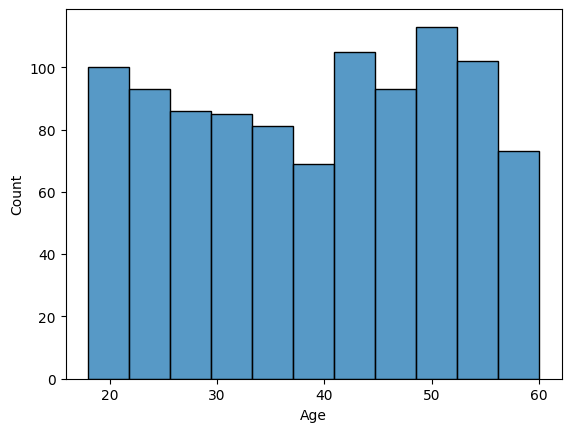

In [12]:
sns.histplot(df["Age"])

<Axes: xlabel='Salary', ylabel='Count'>

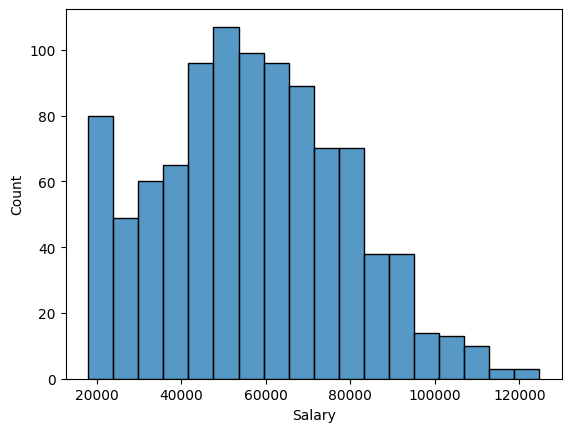

In [13]:
sns.histplot(df["Salary"])

<Axes: xlabel='TimeOnWebsite', ylabel='Count'>

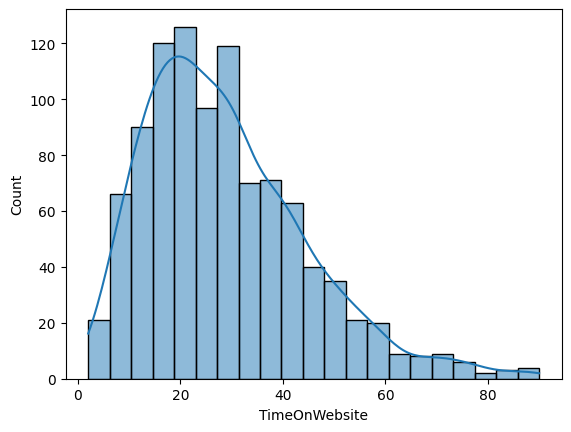

In [15]:
sns.histplot(df["TimeOnWebsite"], kde=True)

## Bivariate and Multivariate EDA

<Axes: xlabel='Age', ylabel='Salary'>

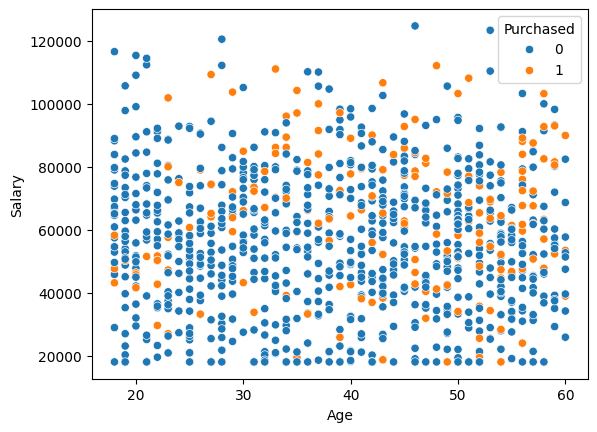

In [20]:
sns.scatterplot(x="Age", y="Salary", data=df, hue="Purchased")

<Axes: xlabel='Salary', ylabel='PreviousPurchases'>

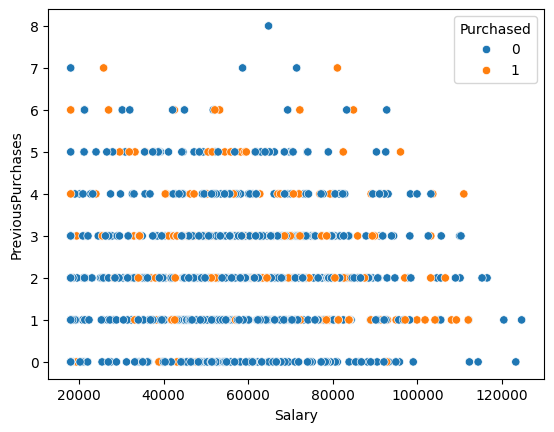

In [86]:
sns.scatterplot(x="Salary", y="PreviousPurchases", data=df, hue="Purchased")

<Axes: >

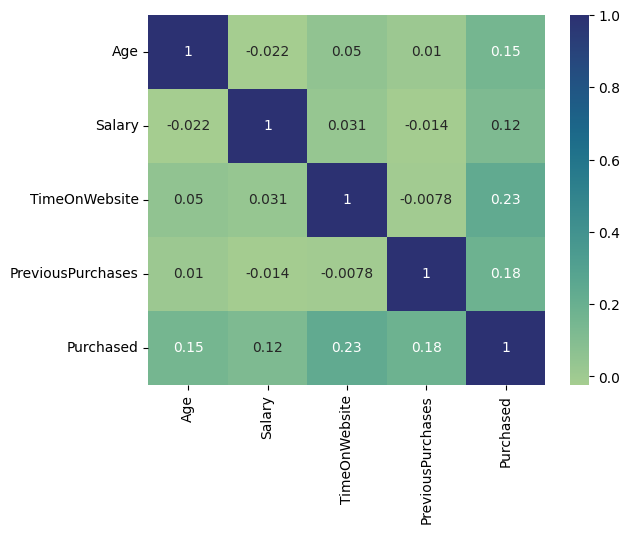

In [78]:
sns.heatmap(df.corr(), cmap="crest", annot=True)

# Seperating Dataset for Training

In [23]:
x = df.drop("Purchased", axis=1)

In [24]:
y = df["Purchased"]

In [25]:
x.head(5)

,Age,Salary,TimeOnWebsite,PreviousPurchases
0,56,91126,29.6,3
1,46,54146,54.3,2
2,32,56915,22.4,1
3,60,34158,47.6,1
4,25,37853,22.9,5


In [26]:
y.head(5)

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

# Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scaling the data

In [89]:
from sklearn.preprocessing import StandardScaler

In [90]:
scaler = StandardScaler()

In [91]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Training the model

In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
model = LogisticRegression()

In [94]:
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Predictions

In [95]:
y_pred = model.predict(x_test_scaled)

In [96]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

# Evaluation

In [97]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [98]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Model:  {accuracy * 100:.2f}%")

Accuracy of Model:  80.00%


In [99]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[159   5]
 [ 35   1]]


Text(50.722222222222214, 0.5, 'Actual')

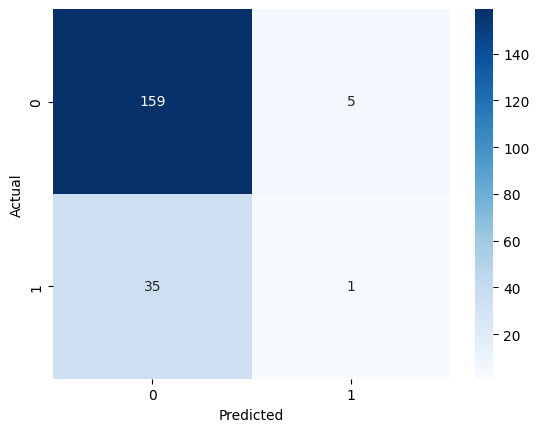

In [100]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [101]:
print(classification_report(y_test, y_pred, target_names=["Not Purchased", "Purchased"]))

               precision    recall  f1-score   support

Not Purchased       0.82      0.97      0.89       164
    Purchased       0.17      0.03      0.05        36

     accuracy                           0.80       200
    macro avg       0.49      0.50      0.47       200
 weighted avg       0.70      0.80      0.74       200



In [102]:
print(model.score(x_train_scaled, y_train))

0.81125


In [103]:
print(model.score(x_test_scaled, y_test))

0.8


# Model Improvement

In [104]:
model = LogisticRegression(class_weight="balanced")

In [105]:
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [106]:
y_pred = model.predict(x_test_scaled)

In [107]:
print(classification_report(y_test, y_pred, target_names=["Not Purchased", "Purchased"]))

               precision    recall  f1-score   support

Not Purchased       0.92      0.76      0.83       164
    Purchased       0.39      0.69      0.50        36

     accuracy                           0.75       200
    macro avg       0.65      0.73      0.67       200
 weighted avg       0.82      0.75      0.77       200



## Model Comparison

| Metric | Original Model | Balanced Model |
|---|---:|---:|
| Accuracy | 80% | 75% |
| Purchased Precision | 17% | 39% |
| Purchased Recall | 3% | 69% |
| Purchased F1-Score | 5% | 50% |

### Observation

The balanced model has a slightly lower overall accuracy (75% vs 80%), but it performs significantly better at identifying customers who actually purchased.

The recall for the **Purchased** class increased from **3% to 69%**, while its F1-score increased from **5% to 50%**. This shows that using `class_weight="balanced"` helped the model handle the class imbalance and identify more actual purchasers.

Although the balanced model sacrifices some overall accuracy, it is more effective when correctly identifying potential purchasers is more important than maximizing overall accuracy.

# Final Model Check

In [108]:
print(f"Training Accuracy: {model.score(x_train_scaled, y_train) *100:.2f}%")
print(f"Testing Accuracy: {model.score(x_test_scaled, y_test) *100:.2f}%")

Training Accuracy: 69.50%
Testing Accuracy: 75.00%


### Class balancing reduced overall accuracy but substantially improved recall for the minority Purchased class.